# 🇪🇺 ECDC European Disease Surveillance

This notebook demonstrates how to access European disease surveillance data from the European Centre for Disease Prevention and Control (ECDC).

**Data Source:** ECDC Surveillance Atlas of Infectious Diseases

**Available Data:**
- COVID-19 surveillance
- Influenza surveillance
- Vaccine-preventable diseases
- Food and waterborne diseases
- Sexually transmitted infections
- Antimicrobial resistance

**Requirements:**
```bash
pip install pandas matplotlib seaborn requests plotly
```

## 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

print("✅ Imports completed!")
print(f"⏰ Current time: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

✅ Imports completed!
⏰ Current time: 2026-03-14 11:38


## 2. ECDC Data Access Functions

In [2]:
class ECDCAccessor:
    """
    Accessor for ECDC surveillance data.
    Uses the ECDC Atlas API and public datasets.
    """
    
    BASE_URL = "https://opendata.ecdc.europa.eu"
    
    # Available datasets
    DATASETS = {
        'covid_cases': '/covid19/casedistribution/json/',
        'covid_hospital': '/covid19/hospitalicuadmissionrates/json/',
        'covid_testing': '/covid19/testing/json/',
        'influenza': '/influenza/surveillance/weeks/json/',
        'measles': '/measles/surveillance/json/'
    }
    
    def get_covid_cases(self, countries=None, year=None):
        """Get COVID-19 case data."""
        url = f"{self.BASE_URL}{self.DATASETS['covid_cases']}"
        
        try:
            response = requests.get(url, timeout=30)
            if response.status_code == 200:
                data = response.json()
                df = pd.DataFrame(data['records'])
                
                # Filter by country if specified
                if countries:
                    df = df[df['geoId'].isin(countries)]
                
                # Filter by year if specified
                if year:
                    df = df[df['year'] == str(year)]
                
                # Convert numeric columns
                numeric_cols = ['cases', 'deaths', 'popData2019']
                for col in numeric_cols:
                    if col in df.columns:
                        df[col] = pd.to_numeric(df[col], errors='coerce')
                
                return df
            else:
                print(f"⚠️ Error: HTTP {response.status_code}")
                return pd.DataFrame()
        except Exception as e:
            print(f"⚠️ Error fetching COVID data: {e}")
            return pd.DataFrame()
    
    def get_influenza_data(self, seasons=None, countries=None):
        """Get influenza surveillance data."""
        url = f"{self.BASE_URL}{self.DATASETS['influenza']}"
        
        try:
            response = requests.get(url, timeout=30)
            if response.status_code == 200:
                data = response.json()
                df = pd.DataFrame(data)
                
                # Filter by country
                if countries:
                    df = df[df['countryname'].isin(countries)]
                
                # Filter by season
                if seasons:
                    df = df[df['season'].isin(seasons)]
                
                return df
            else:
                print(f"⚠️ Error: HTTP {response.status_code}")
                return pd.DataFrame()
        except Exception as e:
            print(f"⚠️ Error fetching influenza data: {e}")
            return pd.DataFrame()

# Initialize accessor
ecdc = ECDCAccessor()
print("✅ ECDC accessor initialized!")

✅ ECDC accessor initialized!


## 3. COVID-19 Analysis

In [3]:
# Download COVID-19 data for selected European countries
print("📥 Downloading COVID-19 data...")

eu_countries = ['DE', 'FR', 'IT', 'ES', 'NL', 'BE', 'AT', 'PT', 'PL', 'SE']

try:
    covid_data = ecdc.get_covid_cases(countries=eu_countries)
    
    print(f"✅ Downloaded {len(covid_data)} records")
    print(f"\n📊 Countries: {covid_data['geoId'].nunique()}")
    print(f"📅 Date range: {covid_data['dateRep'].min()} to {covid_data['dateRep'].max()}")
    
    # Display sample
    print("\n📋 Sample data:")
    display(covid_data[['dateRep', 'geoId', 'countriesAndTerritories', 'cases', 'deaths']].head(10))
    
except Exception as e:
    print(f"⚠️ Error: {e}")
    covid_data = pd.DataFrame()

📥 Downloading COVID-19 data...
✅ Downloaded 3370 records

📊 Countries: 10
📅 Date range: 01/01/2020 to 31/12/2019

📋 Sample data:


,dateRep,geoId,countriesAndTerritories,cases,deaths
3284,14/12/2020,AT,Austria,3005,45
3285,13/12/2020,AT,Austria,2938,96
3286,12/12/2020,AT,Austria,3026,101
3287,11/12/2020,AT,Austria,2466,125
3288,10/12/2020,AT,Austria,2913,126
3289,09/12/2020,AT,Austria,2531,80
3290,08/12/2020,AT,Austria,2181,95
3291,07/12/2020,AT,Austria,2745,58
3292,06/12/2020,AT,Austria,3160,87
3293,05/12/2020,AT,Austria,3634,140


In [4]:
# Process and visualize COVID data
if not covid_data.empty:
    # Convert date
    covid_data['date'] = pd.to_datetime(covid_data['dateRep'], format='%d/%m/%Y')
    
    # Calculate cumulative cases
    covid_data = covid_data.sort_values(['geoId', 'date'])
    covid_data['cumulative_cases'] = covid_data.groupby('geoId')['cases'].cumsum()
    
    # Aggregate by country
    country_totals = covid_data.groupby('geoId').agg({
        'cases': 'sum',
        'deaths': 'sum',
        'popData2019': 'first'
    }).reset_index()
    
    # Calculate rates
    country_totals['cases_per_100k'] = (country_totals['cases'] / country_totals['popData2019']) * 100000
    country_totals['deaths_per_100k'] = (country_totals['deaths'] / country_totals['popData2019']) * 100000
    
    print("📊 COVID-19 Summary by Country:")
    summary = country_totals.sort_values('cases_per_100k', ascending=False)
    display(summary[['geoId', 'cases', 'deaths', 'cases_per_100k', 'deaths_per_100k']].round(2))

📊 COVID-19 Summary by Country:


,geoId,cases,deaths,cases_per_100k,deaths_per_100k
1,BE,608001,17951,5307.49,156.70
3,ES,1730575,47624,3687.01,101.46
0,AT,320036,4400,3612.64,49.67
4,FR,2376852,57911,3546.86,86.42
6,NL,612746,10034,3545.54,58.06
8,PT,348744,5559,3393.57,54.09
9,SE,320098,7514,3128.96,73.45
5,IT,1843712,64520,3054.55,106.89
7,PL,1135676,22864,2990.76,60.21
2,DE,1337078,21975,1610.56,26.47


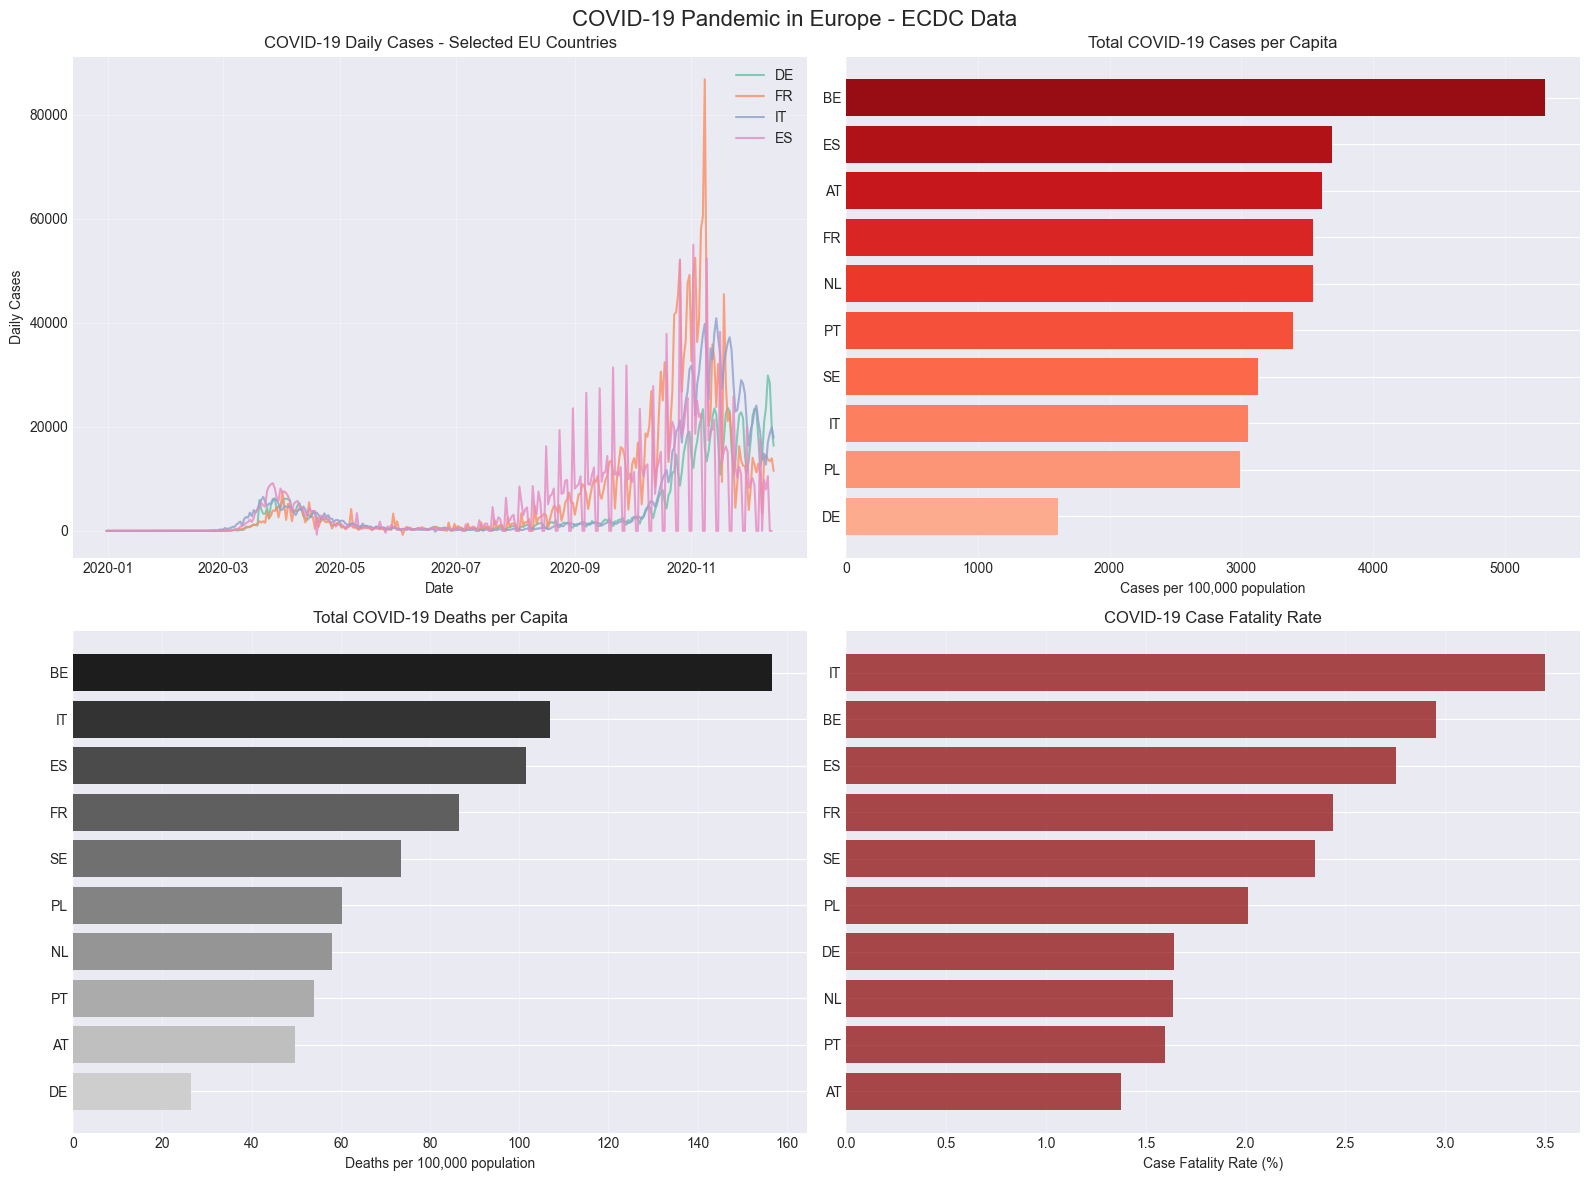

In [5]:
# Visualize COVID-19 cases
if not covid_data.empty:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot 1: Time series of cases
    for country in ['DE', 'FR', 'IT', 'ES']:
        country_data = covid_data[covid_data['geoId'] == country]
        if len(country_data) > 0:
            daily_cases = country_data.groupby('date')['cases'].sum()
            axes[0, 0].plot(daily_cases.index, daily_cases.values, 
                          label=country, linewidth=1.5, alpha=0.8)
    
    axes[0, 0].set_xlabel('Date')
    axes[0, 0].set_ylabel('Daily Cases')
    axes[0, 0].set_title('COVID-19 Daily Cases - Selected EU Countries')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: Total cases per 100k
    country_totals_sorted = country_totals.sort_values('cases_per_100k')
    colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(country_totals_sorted)))
    bars = axes[0, 1].barh(country_totals_sorted['geoId'], 
                          country_totals_sorted['cases_per_100k'],
                          color=colors)
    axes[0, 1].set_xlabel('Cases per 100,000 population')
    axes[0, 1].set_title('Total COVID-19 Cases per Capita')
    axes[0, 1].grid(True, alpha=0.3, axis='x')
    
    # Plot 3: Deaths per 100k
    country_deaths_sorted = country_totals.sort_values('deaths_per_100k')
    colors = plt.cm.Greys(np.linspace(0.3, 0.9, len(country_deaths_sorted)))
    bars = axes[1, 0].barh(country_deaths_sorted['geoId'], 
                          country_deaths_sorted['deaths_per_100k'],
                          color=colors)
    axes[1, 0].set_xlabel('Deaths per 100,000 population')
    axes[1, 0].set_title('Total COVID-19 Deaths per Capita')
    axes[1, 0].grid(True, alpha=0.3, axis='x')
    
    # Plot 4: Case fatality rate
    country_totals['cfr'] = (country_totals['deaths'] / country_totals['cases']) * 100
    cfr_sorted = country_totals.sort_values('cfr')
    bars = axes[1, 1].barh(cfr_sorted['geoId'], cfr_sorted['cfr'],
                          color='darkred', alpha=0.7)
    axes[1, 1].set_xlabel('Case Fatality Rate (%)')
    axes[1, 1].set_title('COVID-19 Case Fatality Rate')
    axes[1, 1].grid(True, alpha=0.3, axis='x')
    
    plt.suptitle('COVID-19 Pandemic in Europe - ECDC Data', fontsize=16)
    plt.tight_layout()
    plt.show()

## 4. Influenza Surveillance

In [6]:
# Get influenza data
print("📥 Downloading influenza surveillance data...")

try:
    flu_data = ecdc.get_influenza_data()
    
    print(f"✅ Downloaded {len(flu_data)} records")
    print(f"\n📊 Available seasons: {flu_data['season'].unique()}")
    print(f"📊 Countries: {flu_data['countryname'].nunique()}")
    
    # Display sample
    print("\n📋 Sample data:")
    display(flu_data[['season', 'countryname', 'weeknumber', 'indicator', 'value']].head(10))
    
except Exception as e:
    print(f"⚠️ Error: {e}")
    flu_data = pd.DataFrame()

📥 Downloading influenza surveillance data...
⚠️ Error: HTTP 404
✅ Downloaded 0 records
⚠️ Error: 'season'


In [7]:
# Analyze influenza trends
if not flu_data.empty:
    # Filter for total influenza cases
    flu_cases = flu_data[flu_data['indicator'] == 'ILI']
    
    # Select recent seasons
    recent_seasons = ['2022-23', '2023-24']
    recent_flu = flu_cases[flu_cases['season'].isin(recent_seasons)]
    
    # Aggregate by season and week
    weekly_flu = recent_flu.groupby(['season', 'weeknumber'])['value'].sum().reset_index()
    
    # Visualize
    fig, ax = plt.subplots(figsize=(12, 6))
    
    for season in recent_seasons:
        season_data = weekly_flu[weekly_flu['season'] == season]
        if len(season_data) > 0:
            ax.plot(season_data['weeknumber'], season_data['value'],
                   marker='o', linewidth=2, label=f'Season {season}')
    
    ax.set_xlabel('Week Number')
    ax.set_ylabel('ILI Cases (per 100,000)')
    ax.set_title('Influenza-like Illness (ILI) Surveillance - Europe')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Peak week analysis
    print("\n📊 Influenza Season Analysis:")
    for season in recent_seasons:
        season_data = weekly_flu[weekly_flu['season'] == season]
        if len(season_data) > 0:
            peak_week = season_data.loc[season_data['value'].idxmax()]
            print(f"  {season}: Peak week {int(peak_week['weeknumber'])} "
                  f"({peak_week['value']:.1f} cases per 100k)")

## 5. Comparative Analysis: COVID-19 Waves

In [8]:
# Analyze COVID-19 waves by country
if not covid_data.empty:
    print("📊 Analyzing COVID-19 waves...\n")
    
    # Calculate 7-day rolling average
    covid_data['cases_7day'] = covid_data.groupby('geoId')['cases'].transform(
        lambda x: x.rolling(window=7, min_periods=1).mean()
    )
    
    # Identify waves (simplified: periods with >500 cases per day)
    wave_analysis = {}
    
    for country in ['DE', 'FR', 'IT']:
        country_data = covid_data[covid_data['geoId'] == country].sort_values('date')
        if len(country_data) > 0:
            # Find peak dates
            peak_date = country_data.loc[country_data['cases'].idxmax(), 'date']
            max_cases = country_data['cases'].max()
            total_cases = country_data['cases'].sum()
            
            wave_analysis[country] = {
                'peak_date': peak_date,
                'max_daily': max_cases,
                'total_cases': total_cases
            }
    
    # Display wave analysis
    print("🌊 COVID-19 Wave Analysis:")
    for country, data in wave_analysis.items():
        print(f"\n  {country}:")
        print(f"    Peak date: {data['peak_date'].strftime('%Y-%m-%d')}")
        print(f"    Max daily cases: {data['max_daily']:,.0f}")
        print(f"    Total cases: {data['total_cases']:,.0f}")

📊 Analyzing COVID-19 waves...

🌊 COVID-19 Wave Analysis:

  DE:
    Peak date: 2020-12-11
    Max daily cases: 29,875
    Total cases: 1,337,078

  FR:
    Peak date: 2020-11-08
    Max daily cases: 86,852
    Total cases: 2,376,852

  IT:
    Peak date: 2020-11-14
    Max daily cases: 40,902
    Total cases: 1,843,712


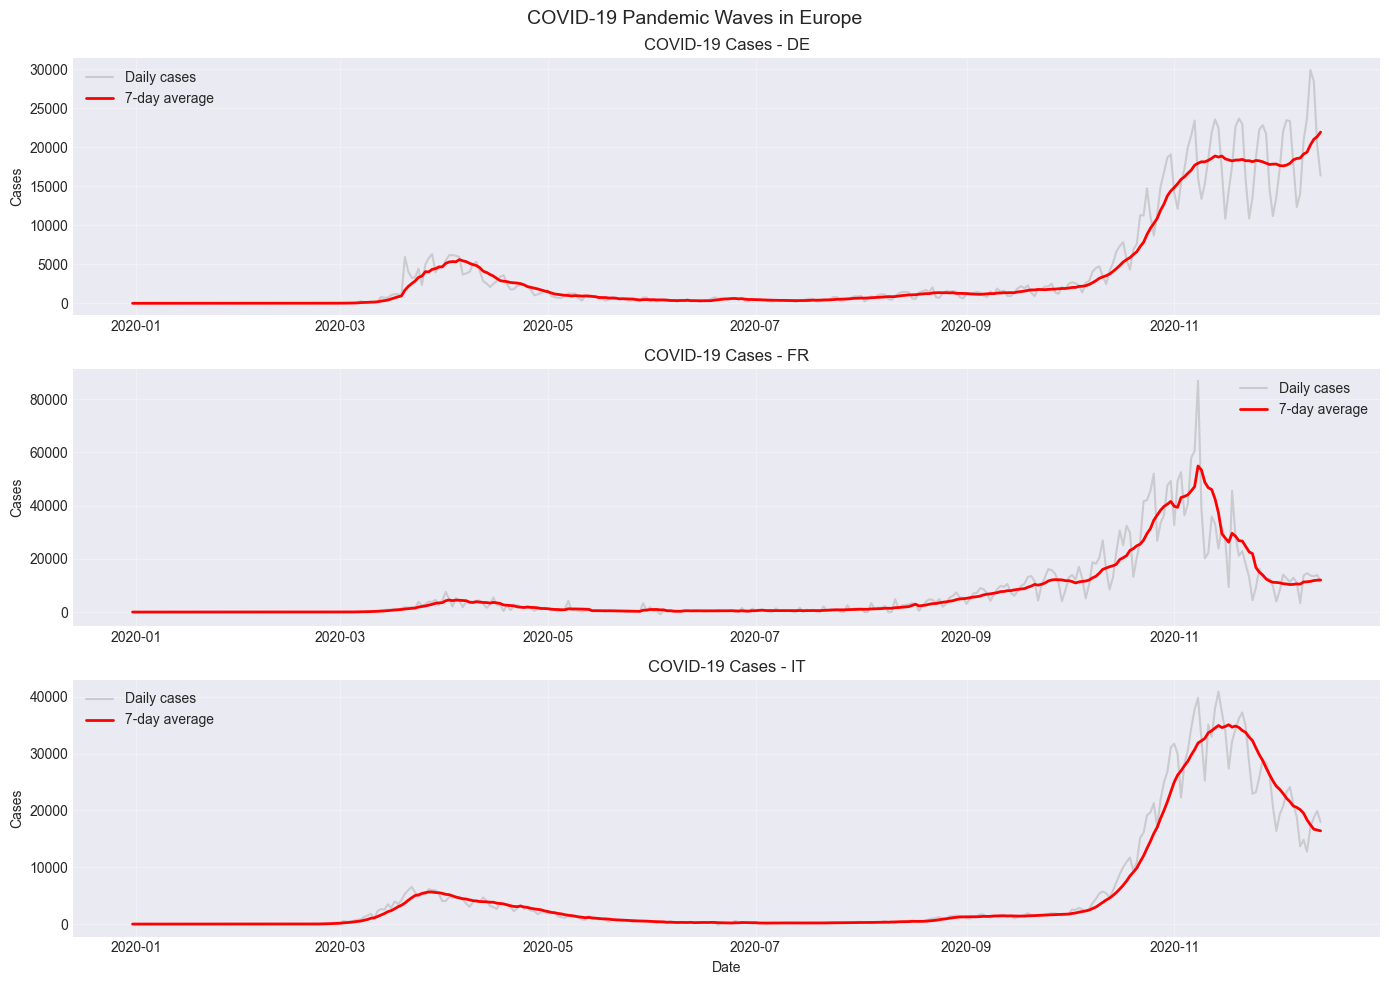

In [9]:
# Visualize waves for selected countries
if not covid_data.empty:
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))
    
    countries_wave = ['DE', 'FR', 'IT']
    
    for i, country in enumerate(countries_wave):
        country_data = covid_data[covid_data['geoId'] == country].sort_values('date')
        
        if len(country_data) > 0:
            # Plot daily cases
            axes[i].plot(country_data['date'], country_data['cases'],
                        alpha=0.3, color='gray', label='Daily cases')
            
            # Plot 7-day average
            axes[i].plot(country_data['date'], country_data['cases_7day'],
                        linewidth=2, color='red', label='7-day average')
            
            axes[i].set_ylabel('Cases')
            axes[i].set_title(f'COVID-19 Cases - {country}')
            axes[i].legend()
            axes[i].grid(True, alpha=0.3)
    
    axes[-1].set_xlabel('Date')
    plt.suptitle('COVID-19 Pandemic Waves in Europe', fontsize=14)
    plt.tight_layout()
    plt.show()

## 6. Export Data

In [10]:
# Save processed data
import os
output_dir = "./output"
os.makedirs(output_dir, exist_ok=True)

datasets = {
    'ecdc_covid_cases.csv': covid_data if 'covid_data' in locals() and not covid_data.empty else None,
    'ecdc_country_totals.csv': country_totals if 'country_totals' in locals() and not country_totals.empty else None,
    'ecdc_influenza.csv': flu_data if 'flu_data' in locals() and not flu_data.empty else None
}

for filename, data in datasets.items():
    if data is not None:
        filepath = os.path.join(output_dir, filename)
        data.to_csv(filepath, index=False)
        print(f"✅ Saved {filename}")

print(f"\n📁 All outputs saved to: {os.path.abspath(output_dir)}/")

✅ Saved ecdc_covid_cases.csv
✅ Saved ecdc_country_totals.csv

📁 All outputs saved to: /home/fccoelho/Documentos/Projects_Software/epidemiological-datasets/examples/notebooks/output/


## 7. Summary

### Key Insights:

1. **COVID-19 Impact**: Significant variation in case rates and mortality across EU countries
2. **Wave Patterns**: Multiple waves with different timing and amplitude across countries
3. **Influenza Surveillance**: Seasonal patterns with predictable peak weeks
4. **Data Quality**: ECDC provides standardized, comparable surveillance data

### Available Datasets:

- COVID-19 cases, hospitalizations, testing
- Influenza surveillance (weekly)
- Vaccine-preventable diseases
- Antimicrobial resistance

### Resources:

- ECDC Atlas: https://atlas.ecdc.europa.eu/public/index.aspx
- ECDC Open Data: https://opendata.ecdc.europa.eu/
- ECDC Main Site: https://www.ecdc.europa.eu/

---

**Notebook created:** 2024
**Author:** Epidemiological Datasets Repository